In [17]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [18]:
# Настройка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [19]:
# Загружаем датасет для задачи регрессии

housing_data = fetch_california_housing()

X_housing_data = housing_data.data
y_housing_data = housing_data.target

print(f"Размер датасета: {X_housing_data.shape}")
print(f"Количество целевых значений: {y_housing_data.shape}")
print(f"Признаки: {housing_data.feature_names}")

Размер датасета: (20640, 8)
Количество целевых значений: (20640,)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [20]:
# Для R-squared нужна задача регрессии, поэтому выберем числовую целевую переменную
print("Целевая переменная: median house value")
print("Статистики целевой переменной:")

print(f"Среднее: {y_housing_data.mean():.2f}")
print(f"Медиана: {np.median(y_housing_data):.2f}")
print(f"Стандартное отклонение: {y_housing_data.std():.2f}")
print(f"Минимум: {y_housing_data.min():.2f}")
print(f"Максимум: {y_housing_data.max():.2f}")

Целевая переменная: median house value
Статистики целевой переменной:
Среднее: 2.07
Медиана: 1.80
Стандартное отклонение: 1.15
Минимум: 0.15
Максимум: 5.00


In [21]:
# Разделяем данные на обучающую и тестовую выборки
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_housing_data,
    y_housing_data,
    test_size=0.3,
    random_state=42
)

print(f"\nРазмеры выборок:")
print(f"  Обучающая: {X_train_reg.shape[0]} образцов")
print(f"  Тестовая: {X_test_reg.shape[0]} образцов")

print("\n🤖 Обучаем модели для предсказания стоимости жилья ...")


Размеры выборок:
  Обучающая: 14448 образцов
  Тестовая: 6192 образцов

🤖 Обучаем модели для предсказания стоимости жилья ...


In [22]:
# Линейная регрессия
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# Случайный лес для регрессии
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [23]:
# Делаем предсказания
lin_pred = lin_reg.predict(X_test_reg)
rf_pred = rf_reg.predict(X_test_reg)

# Вычисляем R-squared
lin_r2 = r2_score(y_test_reg, lin_pred)
rf_r2 = r2_score(y_test_reg, rf_pred)

In [24]:
# Вычисляем MAE и RMSE для дополнительной информации
from sklearn.metrics import mean_absolute_error
lin_mae = mean_absolute_error(y_test_reg, lin_pred)
rf_mae = mean_absolute_error(y_test_reg, rf_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test_reg, lin_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_pred))

print("📈 Результаты предсказания стоимости жилья:")

print("\nЛинейная регрессия:")
print(f"  - R² = {lin_r2:.4f} (объясняет {lin_r2*100:.2f}% вариативности)")
print(f"  - MAE = {lin_mae:.2f} условных единиц стоимости")
print(f"  - RMSE = {lin_rmse:.2f} условных единиц стоимости")

print("\nСлучайный лес:")
print(f"  - R² = {rf_r2:.4f} (объясняет {rf_r2*100:.2f}% вариативности)")
print(f"  - MAE = {rf_mae:.2f} условных единиц стоимости")
print(f"  - RMSE = {rf_rmse:.2f} условных единиц стоимости")

📈 Результаты предсказания стоимости жилья:

Линейная регрессия:
  - R² = 0.5958 (объясняет 59.58% вариативности)
  - MAE = 0.53 условных единиц стоимости
  - RMSE = 0.73 условных единиц стоимости

Случайный лес:
  - R² = 0.8035 (объясняет 80.35% вариативности)
  - MAE = 0.33 условных единиц стоимости
  - RMSE = 0.51 условных единиц стоимости


In [25]:
# Интерпретация результатов
print("\n🏠 Интерпретация результатов для стоимости жилья:")

def interpret_r2(r2_value, model_name):
    if r2_value > 0.8:
        return f"• {model_name}: отличное качество предсказания стоимости жилья"
    elif r2_value > 0.6:
        return f"• {model_name}: хорошее качество предсказания стоимости жилья"
    elif r2_value > 0.4:
        return f"• {model_name}: умеренное качество предсказания стоимости жилья"
    elif r2_value > 0.2:
        return f"• {model_name}: слабое качество предсказания стоимости жилья"
    else:
        return f"• {model_name}: очень слабое качество предсказания"

print(interpret_r2(lin_r2, "Линейная регрессия"))
print(interpret_r2(rf_r2, "Случайный лес"))


🏠 Интерпретация результатов для стоимости жилья:
• Линейная регрессия: умеренное качество предсказания стоимости жилья
• Случайный лес: отличное качество предсказания стоимости жилья


In [26]:
# Практическое значение
print(f"\n💼 Практическое применение:")
if max(lin_r2, rf_r2) > 0.6:
    print(f"• Модели можно использовать для предварительной оценки стоимости жилья")
    print(f"• Результаты могут быть полезны для анализа факторов, влияющих на стоимость недвижимости")
else:
    print(f"• Модели требуют улучшения для практического применения")
    print(f"• Нужны дополнительные факторы или другие подходы")

# Анализ важности признаков (для случайного леса)

print("\n🎯 Наиболее важные признаки для предсказания стоимости жилья:")

feature_importance = rf_reg.feature_importances_
feature_names = housing_data.feature_names

importance_df = pd.DataFrame({
    "Признак": feature_names,
    "Важность": feature_importance
}).sort_values("Важность", ascending=False)

for i, row in importance_df.head(5).iterrows():
    print(f"{row['Признак']}: {row['Важность']:.4f} ({row['Важность']*100:.1f}%)")


💼 Практическое применение:
• Модели можно использовать для предварительной оценки стоимости жилья
• Результаты могут быть полезны для анализа факторов, влияющих на стоимость недвижимости

🎯 Наиболее важные признаки для предсказания стоимости жилья:
MedInc: 0.5260 (52.6%)
AveOccup: 0.1382 (13.8%)
Latitude: 0.0861 (8.6%)
Longitude: 0.0860 (8.6%)
HouseAge: 0.0546 (5.5%)


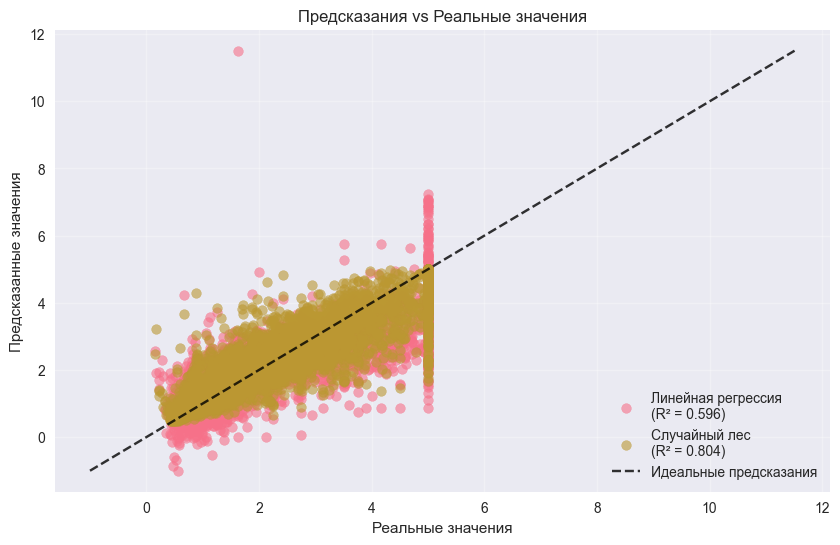

R² для линейной регрессии: 0.596
R² для случайного леса: 0.804
RMSE для линейной регрессии: 0.728 условных единиц стоимости
RMSE для случайного леса: 0.508 условных единиц стоимости


In [27]:
# Строим график предсказаний vs реальных значений
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, lin_pred, alpha=0.6, label=f'Линейная регрессия\n(R² = {lin_r2:.3f})')
plt.scatter(y_test_reg, rf_pred, alpha=0.6, label=f'Случайный лес\n(R² = {rf_r2:.3f})')

# Добавляем идеальную линию
min_val = min(y_test_reg.min(), lin_pred.min(), rf_pred.min())
max_val = max(y_test_reg.max(), lin_pred.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, label='Идеальные предсказания')

plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Предсказания vs Реальные значения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"R² для линейной регрессии: {lin_r2:.3f}")
print(f"R² для случайного леса: {rf_r2:.3f}")
print(f"RMSE для линейной регрессии: {lin_rmse:.3f} условных единиц стоимости")
print(f"RMSE для случайного леса: {rf_rmse:.3f} условных единиц стоимости")

In [28]:
results = pd.DataFrame({
    "Model": ["LinearRegression", "RandomForestRegressor"],
    "R-squared": [lin_r2, rf_r2],
    "MAE": [lin_mae, rf_mae],
    "RMSE": [lin_rmse, rf_rmse],
})

results

,Model,R-squared,MAE,RMSE
0,LinearRegression,0.595770,0.527247,0.728401
1,RandomForestRegressor,0.803507,0.333144,0.507843


## Выводы

В работе был выбран датасет California Housing. Целевая переменная в данном датасете — стоимость жилья, поэтому задача относится к задаче регрессии.

Для сравнения были обучены две модели: LinearRegression и RandomForestRegressor. LinearRegression является линейной моделью и пытается описать зависимость между признаками и целевой переменной с помощью линейной функции. RandomForestRegressor является ансамблевой моделью и может находить более сложные нелинейные зависимости в данных.

Для оценки качества моделей использовались метрики R-squared, MAE и RMSE.

Метрика R-squared показывает, какую часть изменчивости целевой переменной объясняет модель. Чем ближе значение R-squared к 1, тем лучше модель описывает данные.

MAE показывает среднюю абсолютную ошибку модели. Эта метрика помогает понять, насколько в среднем предсказания отличаются от реальных значений. RMSE также показывает ошибку модели, но сильнее штрафует большие отклонения, поэтому она полезна для оценки крупных ошибок.

По результатам оценки RandomForestRegressor показал лучшее качество, чем LinearRegression: значение R-squared у него выше, а значения MAE и RMSE ниже. Это означает, что RandomForestRegressor точнее предсказывает стоимость жилья на тестовой выборке.

Вероятно, лучший результат RandomForestRegressor связан с тем, что данные содержат нелинейные зависимости между признаками, а Random Forest лучше справляется с такими зависимостями по сравнению с простой линейной моделью.

Итог: для выбранного датасета California Housing более подходящей моделью оказалась RandomForestRegressor.
